In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, PrecisionRecallDisplay, RocCurveDisplay, accuracy_score

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/data_banknote_authentication.csv')

In [3]:
data

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [5]:
# 0 - real money
# 1 - fake money

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


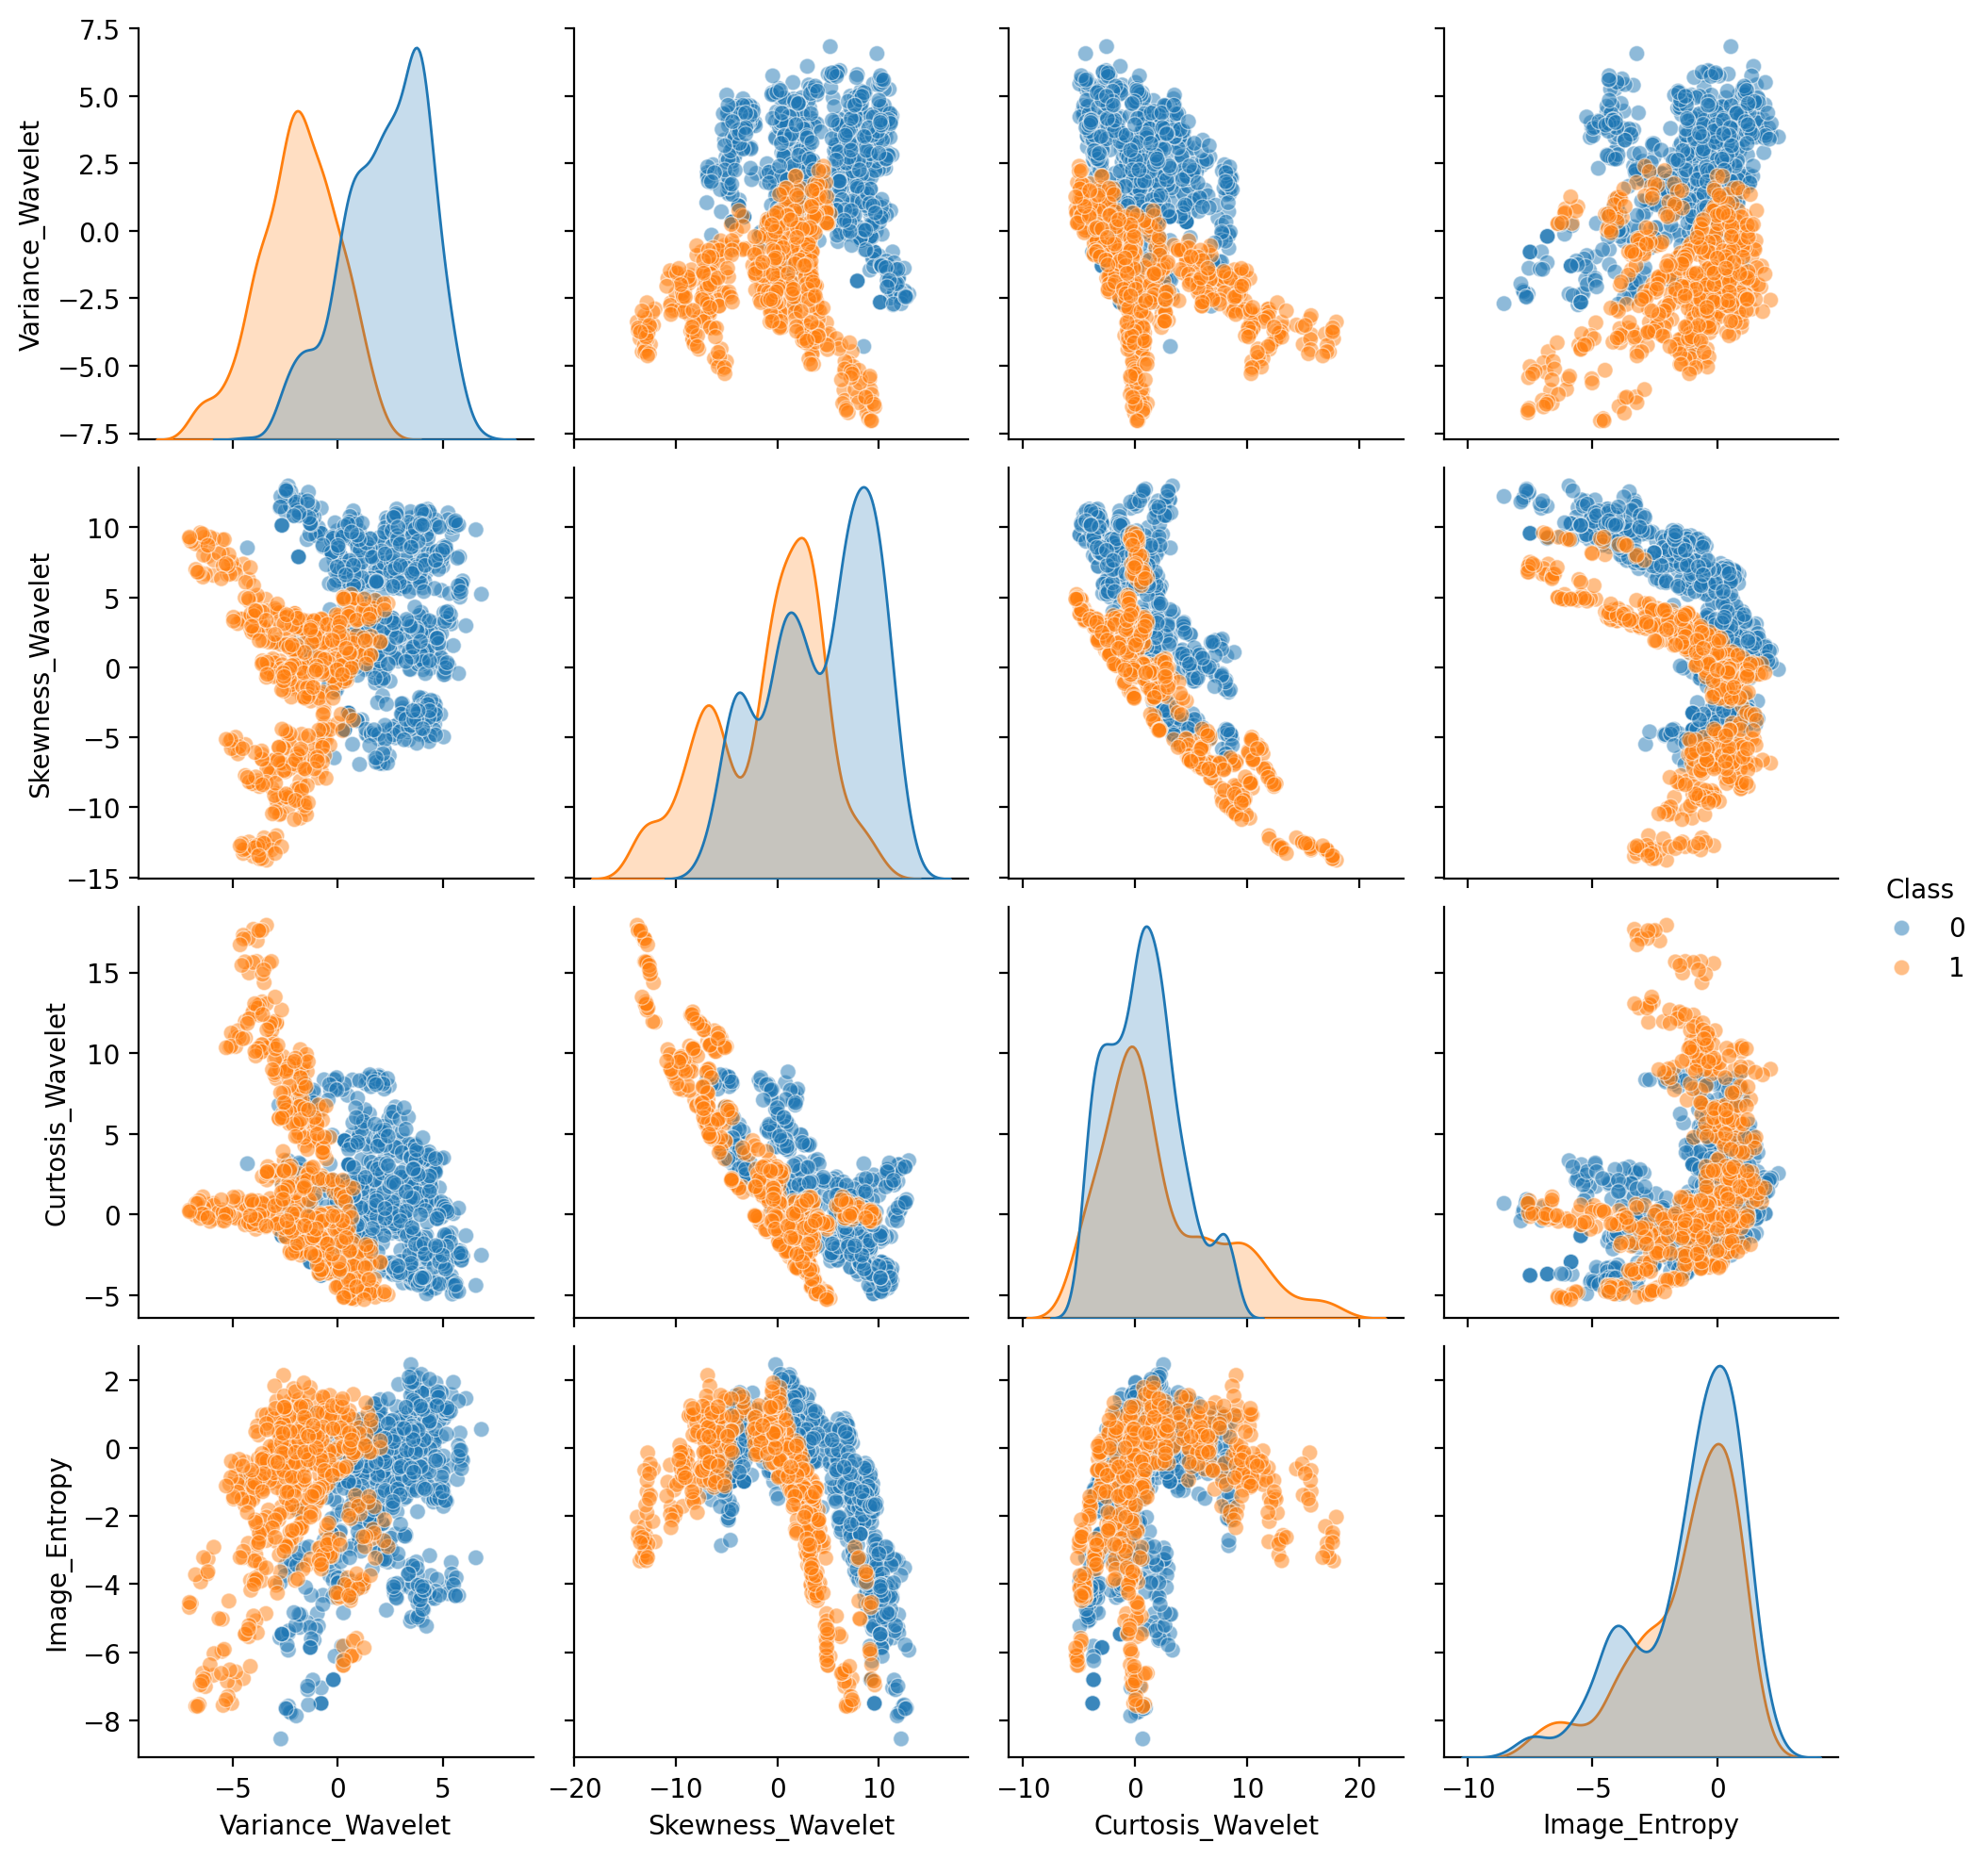

In [43]:
sns.pairplot(data, plot_kws={'alpha': 0.5}, hue = 'Class')

In [8]:
X = data.drop('Class', axis = 1)

In [9]:
y = data['Class']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 101)

In [13]:
n_estimators = [64, 100, 128, 200]

In [14]:
max_features = [2, 3, 4]

In [15]:
bootstrap = [True, False]

In [16]:
oob_score = [True, False]

In [17]:
parameter_grid = {'n_estimators': n_estimators, 'max_features': max_features, 'bootstrap': bootstrap, 'oob_score': oob_score}

In [18]:
forest_model = RandomForestClassifier()

In [19]:
grid_model = GridSearchCV(forest_model, parameter_grid)

In [20]:
grid_model.fit(X_train, y_train)

/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/ensembl

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,64


In [21]:
grid_model.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64, 'oob_score': True}

In [25]:
rfc = RandomForestClassifier(bootstrap =  True, max_features = 2, n_estimators = 64, oob_score = True)

In [29]:
rfc.fit(X_train, y_train)

,n_estimators,64
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [30]:
rfc.oob_score_

0.9948542024013722

In [38]:
def plot_metrics(model, x_test, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'Blues', ax = axes[0])
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax = axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax = axes[2])
    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

In [39]:
y_pred = rfc.predict(X_test)

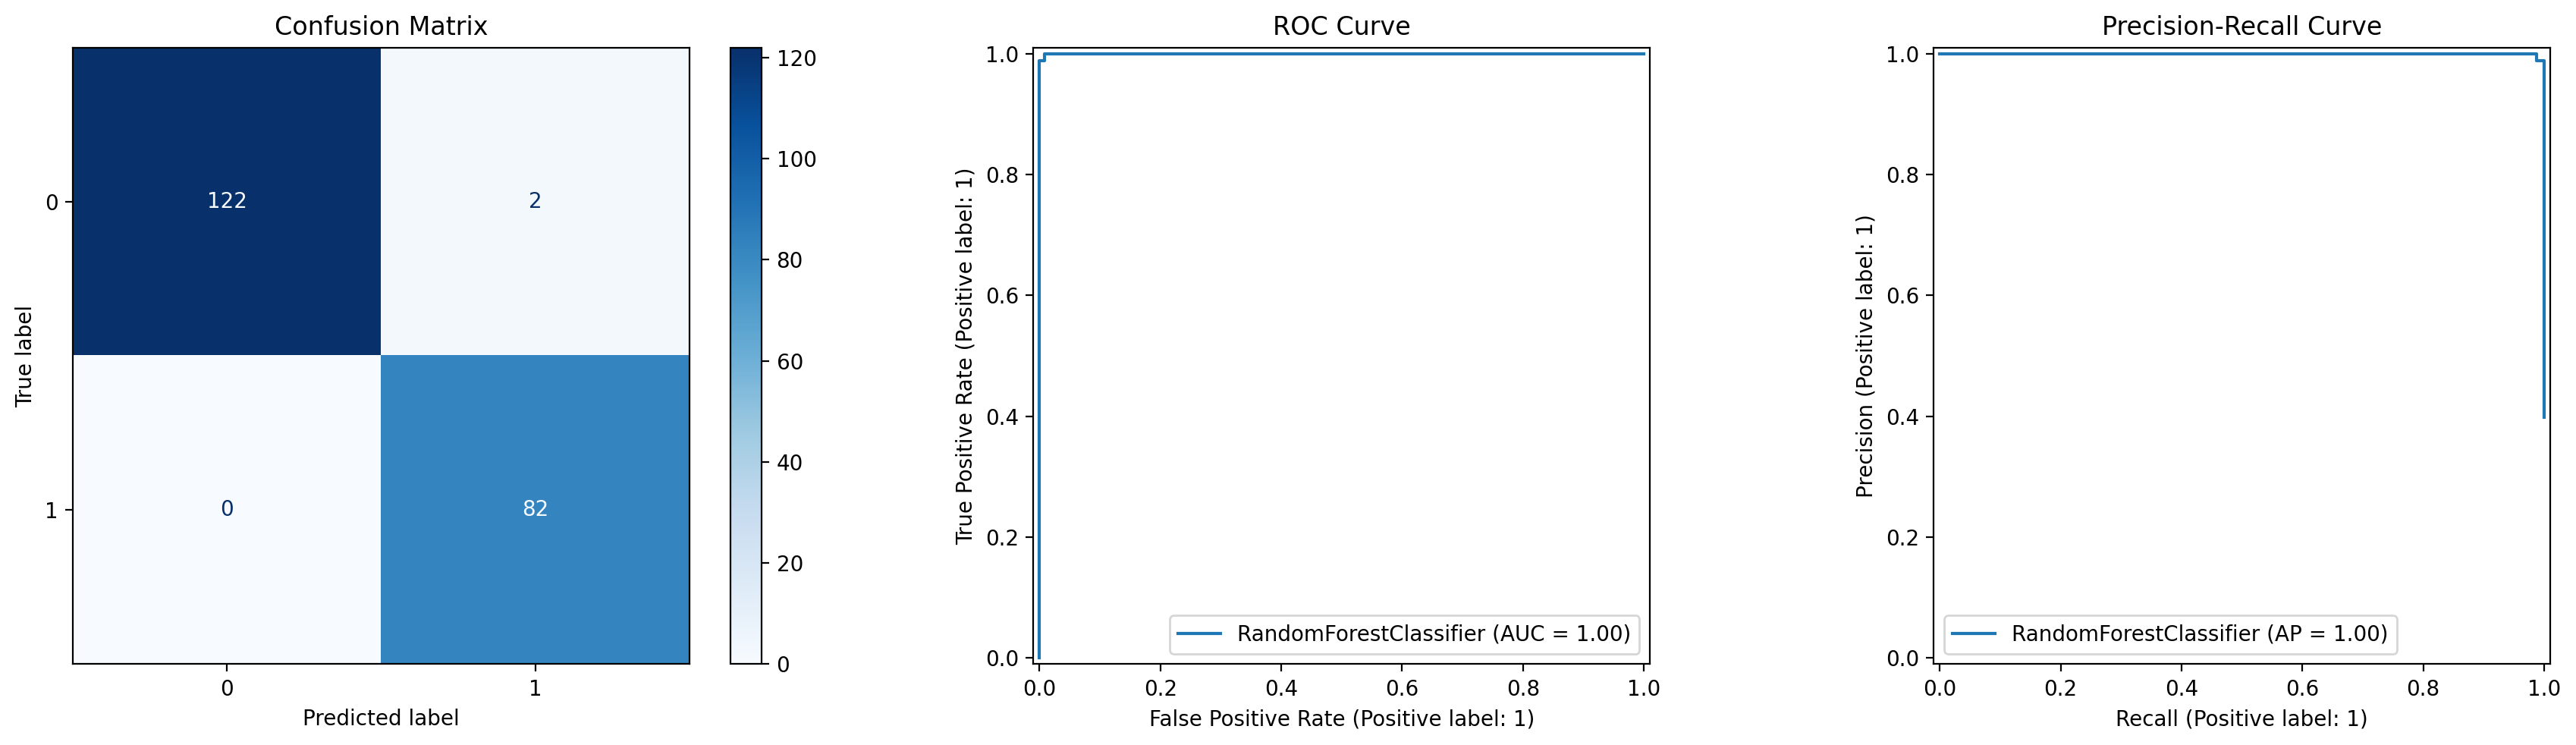

In [40]:
plot_metrics(rfc, X_test, y_test)

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       124
           1       0.98      1.00      0.99        82

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



In [45]:
errors = [ ]

In [46]:
misclassifications = [ ]

In [51]:
np.sum(y_pred != y_test)

np.int64(2)

In [52]:
for i in range(1, 200):
    model = RandomForestClassifier(n_estimators = i, max_features = 2)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    err = 1 - accuracy_score(y_test, preds)
    n_missed = np.sum(preds != y_test)

    errors.append(err)
    misclassifications.append(n_missed)

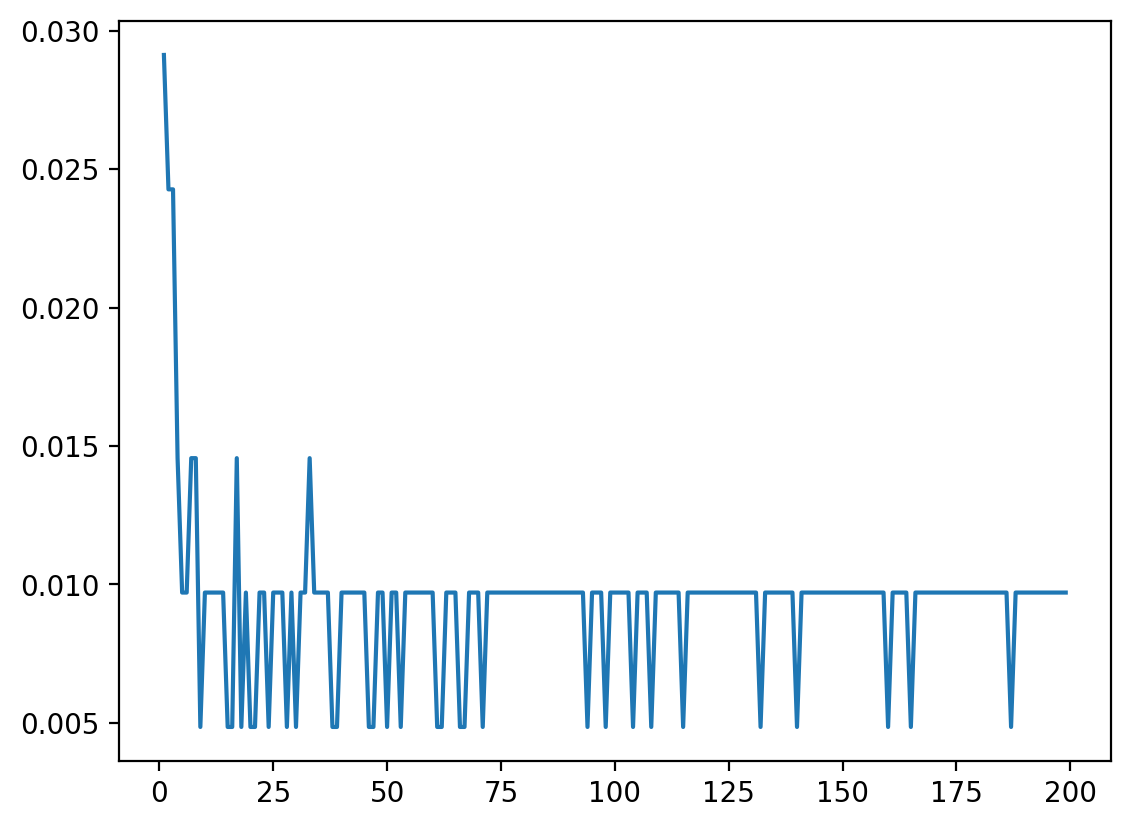

In [53]:
plt.plot(range(1, 200), errors)

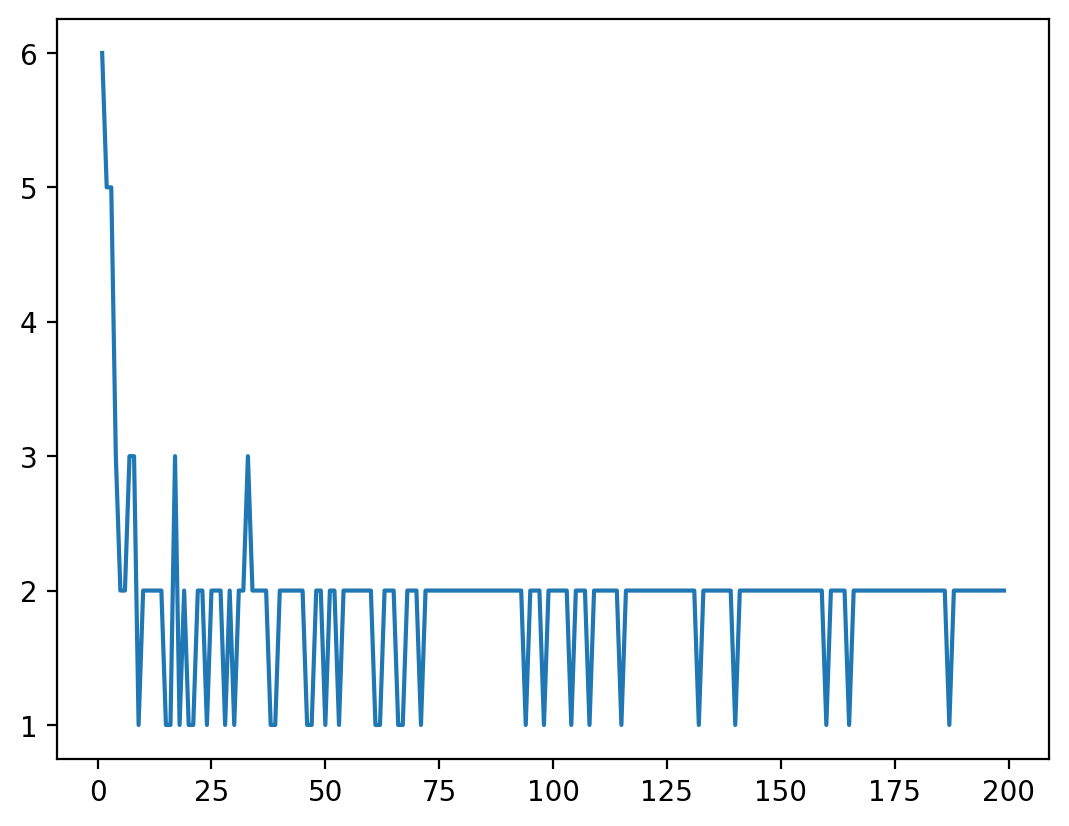

In [54]:
plt.plot(range(1, 200), misclassifications)